# Phase 5: Game Simulation

**Goal:** Run Monte Carlo simulations for single games, playoff series, and full bracket forecasting.

## Table of Contents

- [Imports](#imports)
- [Loading Dataset](#loading-dataset)
- [Model Recreation](#model-recreation)
- [Monte Carlo Game Simulation](#monte-carlo-game-simulation)
- [Manual Test](#manual-test)
- [Using Test Set](#using-test-set)
- [Attach Team/Game Info](#attach-teamgame-info)
- [Full Simulation](#full-simulation)
- [Visualize](#visualize)
- [Best-of-Seven Series Simulation](#best-of-seven-series-simulation)
- [Making More Realistic](#making-more-realistic)
- [Testing for Two Teams](#testing-for-two-teams)
- [Common-Date Team Snapshot](#common-date-team-snapshot)
- [Playoff Bracket Simulation](#playoff-bracket-simulation)
- [Test Bracket](#test-bracket)

---


## Imports

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.calibration import calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, brier_score_loss, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

## Loading Dataset

In [35]:
df = pd.read_csv(
    "../data/processed/team_game_modeling.csv",
    dtype={
        "GAME_ID": "string",
        "SEASON": "string",
        "TEAM_ID": "Int64",
    },
    parse_dates=["GAME_DATE"],
)

df.shape

(12300, 77)

In [36]:
features = [
    "HOME_GAME",
    "REST_DAYS",
    "SEASON_WIN_PCT",
    "TEAM_GAME_NUMBER",
    "PTS_ROLL5",
    "FG_PCT_ROLL5",
    "FG3_PCT_ROLL5",
    "FT_PCT_ROLL5",
    "REB_ROLL5",
    "AST_ROLL5",
    "STL_ROLL5",
    "BLK_ROLL5",
    "TOV_ROLL5",
    "PLUS_MINUS_ROLL5",
    "WIN_PCT_ROLL5",
    "OPP_PTS_ROLL5",
    "OPP_FG_PCT_ROLL5",
    "OPP_FG3_PCT_ROLL5",
    "OPP_FT_PCT_ROLL5",
    "OPP_REB_ROLL5",
    "OPP_AST_ROLL5",
    "OPP_STL_ROLL5",
    "OPP_BLK_ROLL5",
    "OPP_TOV_ROLL5",
    "OPP_PLUS_MINUS_ROLL5",
    "OPP_WIN_PCT_ROLL5",
    "OPP_REST_DAYS",
    "PTS_ROLL5_DIFF",
    "FG_PCT_ROLL5_DIFF",
    "FG3_PCT_ROLL5_DIFF",
    "REB_ROLL5_DIFF",
    "AST_ROLL5_DIFF",
    "TOV_ROLL5_DIFF",
    "PLUS_MINUS_ROLL5_DIFF",
    "WIN_PCT_ROLL5_DIFF",
    "REST_DAYS_DIFF",
]

target = "WIN"

## Model Recreation

In [37]:
train_df = df[df["SEASON"] != "2025-26"].copy()
test_df = df[df["SEASON"] == "2025-26"].copy()

train_df = train_df.dropna(subset=features)
test_df = test_df.dropna(subset=features)

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("Training:", X_train.shape)
print("Test:", X_test.shape)

Training: (9714, 36)
Test: (2428, 36)


In [38]:
logistic_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                random_state=42,
                max_iter=1000,
            ),
        ),
    ]
)

logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](36,)","['HOME_GAME','REST_DAYS','SEASON_WIN_PCT',...,'PLUS_MINUS_ROLL5_DIFF', 'WIN_PCT_ROLL5_DIFF','REST_DAYS_DIFF']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,36
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [39]:
random_forest = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
)

random_forest.fit(
    X_train,
    y_train,
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total n

## Monte Carlo Game Simulation

Monte Carlo simulation is used to model uncertainty by repeatedly generating possible game outcomes from a predicted win probability. Over many simulations, the proportion of wins approaches the model's estimated probability.

In [ ]:
def simulate_game(win_probability, n_simulations=10000, random_state=42):
    rng = np.random.default_rng(random_state)

    simulations = rng.random(n_simulations)

    wins = simulations < win_probability

    simulated_win_rate = wins.mean()

    return simulated_win_rate

### Manual Test

In [41]:
example_probability = 0.64

simulated_win_rate = simulate_game(
    example_probability,
    n_simulations=10000
)

print(
    f"Model Win Probability: {example_probability:.1%}"
)

print(
    f"Simulated Win Rate: {simulated_win_rate:.1%}"
)

Model Win Probability: 64.0%


TypeError: unsupported format string passed to dict.__format__

### Using Test Set

In [ ]:
game_position = 0

game_features = X_test.iloc[[game_position]]

win_probability = logistic_model.predict_proba(
    game_features
)[0, 1]

print(
    f"Predicted Win Probability: {win_probability:.1%}"
)

Predicted Win Probability: 14.3%


In [ ]:
simulated_win_rate = simulate_game(
    win_probability,
    n_simulations=10000
)

print(
    f"Simulated Win Rate: {simulated_win_rate:.1%}"
)

Simulated Win Rate: 14.3%


### Attach Team/Game Info

In [ ]:
game_index = X_test.index[game_position]

game_info = test_df.loc[
    game_index,
    [
        "GAME_ID",
        "GAME_DATE",
        "TEAM_NAME",
        "WIN",
    ]
]

game_info

GAME_ID               0022500090
GAME_DATE    2025-10-24 00:00:00
TEAM_NAME          Atlanta Hawks
WIN                            1
Name: 329, dtype: object

In [ ]:
print(f"Team: {game_info['TEAM_NAME']}")
print(f"Date: {game_info['GAME_DATE']}")
print(f"Actual Result: {game_info['WIN']}")
print(f"Predicted Win Probability: {win_probability:.1%}")
print(f"Simulated Win Rate: {simulated_win_rate:.1%}")

Team: Atlanta Hawks
Date: 2025-10-24 00:00:00
Actual Result: 1
Predicted Win Probability: 14.3%
Simulated Win Rate: 14.3%


### Full Simulation

In [44]:
def simulate_game(win_probability, n_simulations=10000, random_state=42):
    rng = np.random.default_rng(random_state)

    simulations = rng.random(n_simulations)

    wins = int((simulations < win_probability).sum())
    losses = int(n_simulations - wins)

    return {
        "Simulations": n_simulations,
        "Wins": wins,
        "Losses": losses,
        "Simulated Win Rate": wins / n_simulations,
    }

In [45]:
simulation_results = simulate_game(
    win_probability,
    n_simulations=10000
)

simulation_results

{'Simulations': 10000,
 'Wins': 1434,
 'Losses': 8566,
 'Simulated Win Rate': 0.1434}

### Visualize

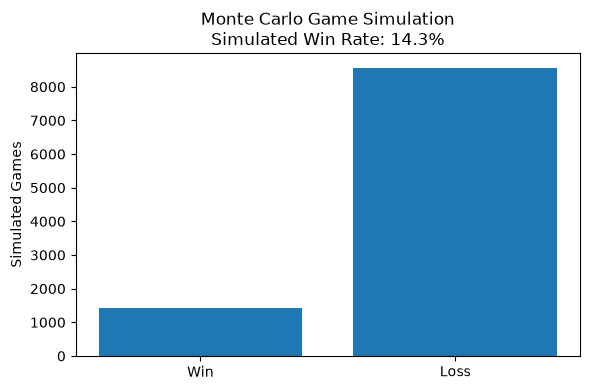

In [48]:
plt.figure(figsize=(6, 4))

plt.bar(
    results_df["Outcome"],
    results_df["Count"]
)

plt.ylabel("Simulated Games")
plt.title(
    f"Monte Carlo Game Simulation\n"
    f"Simulated Win Rate: {simulation_results['Simulated Win Rate']:.1%}"
)

plt.tight_layout()
plt.show()

## Best-of-Seven Series Simulation

A playoff series is simulated by repeatedly generating individual game outcomes until one team reaches four wins. Repeating this process many times estimates the probability of winning the series as well as the distribution of possible series lengths.

In [49]:
def simulate_series(
    win_probability,
    n_simulations=10000,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    series_wins = 0
    series_losses = 0
    series_lengths = []

    for _ in range(n_simulations):
        team_wins = 0
        opponent_wins = 0

        while team_wins < 4 and opponent_wins < 4:
            if rng.random() < win_probability:
                team_wins += 1
            else:
                opponent_wins += 1

        if team_wins == 4:
            series_wins += 1
        else:
            series_losses += 1

        series_lengths.append(team_wins + opponent_wins)

    return {
        "Simulations": n_simulations,
        "Series Wins": series_wins,
        "Series Losses": series_losses,
        "Series Win Rate": series_wins / n_simulations,
        "Average Series Length": np.mean(series_lengths),
        "Series Lengths": series_lengths,
    }

In [50]:
series_results = simulate_series(
    win_probability,
    n_simulations=10000
)

print(f"Single-Game Win Probability: {win_probability:.1%}")
print(f"Series Win Probability: {series_results['Series Win Rate']:.1%}")
print(f"Average Series Length: {series_results['Average Series Length']:.2f} games")

Single-Game Win Probability: 14.3%
Series Win Probability: 1.1%
Average Series Length: 4.64 games


In [51]:
series_length_counts = (
    pd.Series(series_results["Series Lengths"])
    .value_counts()
    .sort_index()
)

series_length_counts

4    5393
5    3149
6    1106
7     352
Name: count, dtype: int64

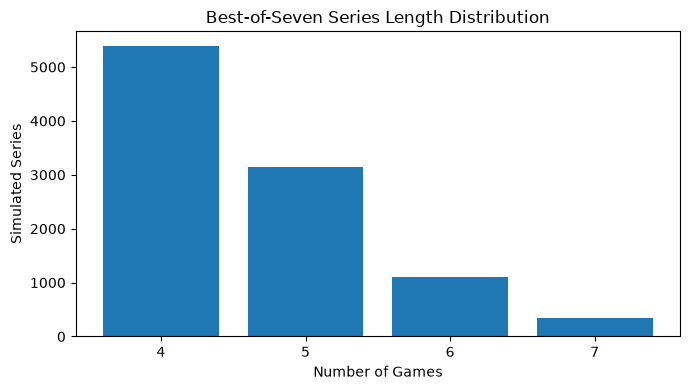

In [52]:
plt.figure(figsize=(7, 4))

plt.bar(
    series_length_counts.index.astype(str),
    series_length_counts.values
)

plt.xlabel("Number of Games")
plt.ylabel("Simulated Series")
plt.title("Best-of-Seven Series Length Distribution")

plt.tight_layout()
plt.show()

### Making More Realistic

Changing win probability based on home/away game location

In [53]:
def simulate_series_home_away(
    home_win_probability,
    away_win_probability,
    n_simulations=10000,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    home_pattern = [
        True,
        True,
        False,
        False,
        True,
        False,
        True
    ]

    series_wins = 0
    series_losses = 0
    series_lengths = []

    for _ in range(n_simulations):
        team_wins = 0
        opponent_wins = 0

        for game_number, is_home in enumerate(home_pattern):
            win_probability = (
                home_win_probability
                if is_home
                else away_win_probability
            )

            if rng.random() < win_probability:
                team_wins += 1
            else:
                opponent_wins += 1

            if team_wins == 4 or opponent_wins == 4:
                series_lengths.append(game_number + 1)
                break

        if team_wins == 4:
            series_wins += 1
        else:
            series_losses += 1

    return {
        "Simulations": n_simulations,
        "Series Wins": series_wins,
        "Series Losses": series_losses,
        "Series Win Rate": series_wins / n_simulations,
        "Average Series Length": np.mean(series_lengths),
        "Series Lengths": series_lengths
    }

In [54]:
home_probability = 0.65
away_probability = 0.55

series_results = simulate_series_home_away(
    home_probability,
    away_probability,
    n_simulations=10000
)

print(f"Home Win Probability: {home_probability:.1%}")
print(f"Away Win Probability: {away_probability:.1%}")
print(f"Series Win Probability: {series_results['Series Win Rate']:.1%}")
print(f"Average Series Length: {series_results['Average Series Length']:.2f}")

Home Win Probability: 65.0%
Away Win Probability: 55.0%
Series Win Probability: 72.4%
Average Series Length: 5.71


### Testing for Two Teams

In [55]:
team_a = "Boston Celtics"
team_b = "Oklahoma City Thunder"

In [57]:
team_a_row = (
    df[df["TEAM_NAME"] == team_a]
    .sort_values("GAME_DATE")
    .iloc[-1]
)

team_b_row = (
    df[df["TEAM_NAME"] == team_b]
    .sort_values("GAME_DATE")
    .iloc[-1]
)

print(team_a_row["GAME_DATE"])
print(team_b_row["GAME_DATE"])

2026-04-12 00:00:00
2026-04-12 00:00:00


In [58]:
matchup = pd.DataFrame(index=[0])

matchup["HOME_GAME"] = [1]
matchup["REST_DAYS"] = [team_a_row["REST_DAYS"]]
matchup["SEASON_WIN_PCT"] = [team_a_row["SEASON_WIN_PCT"]]
matchup["TEAM_GAME_NUMBER"] = [team_a_row["TEAM_GAME_NUMBER"]]

matchup["PTS_ROLL5"] = [team_a_row["PTS_ROLL5"]]
matchup["FG_PCT_ROLL5"] = [team_a_row["FG_PCT_ROLL5"]]
matchup["FG3_PCT_ROLL5"] = [team_a_row["FG3_PCT_ROLL5"]]
matchup["FT_PCT_ROLL5"] = [team_a_row["FT_PCT_ROLL5"]]
matchup["REB_ROLL5"] = [team_a_row["REB_ROLL5"]]
matchup["AST_ROLL5"] = [team_a_row["AST_ROLL5"]]
matchup["STL_ROLL5"] = [team_a_row["STL_ROLL5"]]
matchup["BLK_ROLL5"] = [team_a_row["BLK_ROLL5"]]
matchup["TOV_ROLL5"] = [team_a_row["TOV_ROLL5"]]
matchup["PLUS_MINUS_ROLL5"] = [team_a_row["PLUS_MINUS_ROLL5"]]
matchup["WIN_PCT_ROLL5"] = [team_a_row["WIN_PCT_ROLL5"]]

In [60]:
matchup["OPP_PTS_ROLL5"] = [team_b_row["PTS_ROLL5"]]
matchup["OPP_FG_PCT_ROLL5"] = [team_b_row["FG_PCT_ROLL5"]]
matchup["OPP_FG3_PCT_ROLL5"] = [team_b_row["FG3_PCT_ROLL5"]]
matchup["OPP_FT_PCT_ROLL5"] = [team_b_row["FT_PCT_ROLL5"]]
matchup["OPP_REB_ROLL5"] = [team_b_row["REB_ROLL5"]]
matchup["OPP_AST_ROLL5"] = [team_b_row["AST_ROLL5"]]
matchup["OPP_STL_ROLL5"] = [team_b_row["STL_ROLL5"]]
matchup["OPP_BLK_ROLL5"] = [team_b_row["BLK_ROLL5"]]
matchup["OPP_TOV_ROLL5"] = [team_b_row["TOV_ROLL5"]]
matchup["OPP_PLUS_MINUS_ROLL5"] = [team_b_row["PLUS_MINUS_ROLL5"]]
matchup["OPP_WIN_PCT_ROLL5"] = [team_b_row["WIN_PCT_ROLL5"]]
matchup["OPP_REST_DAYS"] = [team_b_row["REST_DAYS"]]

In [61]:
matchup["PTS_ROLL5_DIFF"] = (
    matchup["PTS_ROLL5"]
    - matchup["OPP_PTS_ROLL5"]
)

matchup["FG_PCT_ROLL5_DIFF"] = (
    matchup["FG_PCT_ROLL5"]
    - matchup["OPP_FG_PCT_ROLL5"]
)

matchup["FG3_PCT_ROLL5_DIFF"] = (
    matchup["FG3_PCT_ROLL5"]
    - matchup["OPP_FG3_PCT_ROLL5"]
)

matchup["REB_ROLL5_DIFF"] = (
    matchup["REB_ROLL5"]
    - matchup["OPP_REB_ROLL5"]
)

matchup["AST_ROLL5_DIFF"] = (
    matchup["AST_ROLL5"]
    - matchup["OPP_AST_ROLL5"]
)

matchup["TOV_ROLL5_DIFF"] = (
    matchup["TOV_ROLL5"]
    - matchup["OPP_TOV_ROLL5"]
)

matchup["PLUS_MINUS_ROLL5_DIFF"] = (
    matchup["PLUS_MINUS_ROLL5"]
    - matchup["OPP_PLUS_MINUS_ROLL5"]
)

matchup["WIN_PCT_ROLL5_DIFF"] = (
    matchup["WIN_PCT_ROLL5"]
    - matchup["OPP_WIN_PCT_ROLL5"]
)

matchup["REST_DAYS_DIFF"] = (
    matchup["REST_DAYS"]
    - matchup["OPP_REST_DAYS"]
)

In [62]:
matchup = matchup[features]

#### Predicting

In [63]:
home_matchup = matchup.copy()

home_matchup["HOME_GAME"] = 1

home_probability = logistic_model.predict_proba(
    home_matchup
)[0, 1]

print(
    f"{team_a} home win probability vs {team_b}: "
    f"{home_probability:.1%}"
)

Boston Celtics home win probability vs Oklahoma City Thunder: 49.3%


In [64]:
away_matchup = matchup.copy()

away_matchup["HOME_GAME"] = 0

away_probability = logistic_model.predict_proba(
    away_matchup
)[0, 1]

print(
    f"{team_a} away win probability vs {team_b}: "
    f"{away_probability:.1%}"
)

Boston Celtics away win probability vs Oklahoma City Thunder: 38.2%


In [65]:
series_results = simulate_series_home_away(
    home_probability,
    away_probability,
    n_simulations=10000
)

print(f"Matchup: {team_a} vs {team_b}")
print(f"{team_a} Home Win Probability: {home_probability:.1%}")
print(f"{team_a} Away Win Probability: {away_probability:.1%}")
print(
    f"{team_a} Series Win Probability: "
    f"{series_results['Series Win Rate']:.1%}"
)
print(
    f"Average Series Length: "
    f"{series_results['Average Series Length']:.2f}"
)

Matchup: Boston Celtics vs Oklahoma City Thunder
Boston Celtics Home Win Probability: 49.3%
Boston Celtics Away Win Probability: 38.2%
Boston Celtics Series Win Probability: 37.6%
Average Series Length: 5.78


## Common-Date Team Snapshot

To ensure matchup simulations compare teams using information available at the same point in time, each team's most recent observation on or before a selected snapshot date is used.

In [66]:
def get_team_snapshot(df, team_name, snapshot_date):
    team_df = df[
        (df["TEAM_NAME"] == team_name)
        & (df["GAME_DATE"] <= snapshot_date)
    ].sort_values("GAME_DATE")

    if team_df.empty:
        raise ValueError(
            f"No data available for {team_name} on or before {snapshot_date}"
        )

    return team_df.iloc[-1]

In [67]:
snapshot_date = pd.Timestamp("2026-04-12")

team_a_row = get_team_snapshot(
    df,
    team_a,
    snapshot_date
)

team_b_row = get_team_snapshot(
    df,
    team_b,
    snapshot_date
)

print(team_a, team_a_row["GAME_DATE"])
print(team_b, team_b_row["GAME_DATE"])

Boston Celtics 2026-04-12 00:00:00
Oklahoma City Thunder 2026-04-12 00:00:00


In [68]:
def build_matchup_row(team_row, opponent_row, home_game):
    matchup = pd.DataFrame(index=[0])

    matchup["HOME_GAME"] = [home_game]
    matchup["REST_DAYS"] = [team_row["REST_DAYS"]]
    matchup["SEASON_WIN_PCT"] = [team_row["SEASON_WIN_PCT"]]
    matchup["TEAM_GAME_NUMBER"] = [team_row["TEAM_GAME_NUMBER"]]

    team_stats = [
        "PTS_ROLL5",
        "FG_PCT_ROLL5",
        "FG3_PCT_ROLL5",
        "FT_PCT_ROLL5",
        "REB_ROLL5",
        "AST_ROLL5",
        "STL_ROLL5",
        "BLK_ROLL5",
        "TOV_ROLL5",
        "PLUS_MINUS_ROLL5",
        "WIN_PCT_ROLL5",
    ]

    for stat in team_stats:
        matchup[stat] = [team_row[stat]]
        matchup[f"OPP_{stat}"] = [opponent_row[stat]]

    matchup["OPP_REST_DAYS"] = [opponent_row["REST_DAYS"]]

    matchup["PTS_ROLL5_DIFF"] = (
        matchup["PTS_ROLL5"] - matchup["OPP_PTS_ROLL5"]
    )

    matchup["FG_PCT_ROLL5_DIFF"] = (
        matchup["FG_PCT_ROLL5"] - matchup["OPP_FG_PCT_ROLL5"]
    )

    matchup["FG3_PCT_ROLL5_DIFF"] = (
        matchup["FG3_PCT_ROLL5"] - matchup["OPP_FG3_PCT_ROLL5"]
    )

    matchup["REB_ROLL5_DIFF"] = (
        matchup["REB_ROLL5"] - matchup["OPP_REB_ROLL5"]
    )

    matchup["AST_ROLL5_DIFF"] = (
        matchup["AST_ROLL5"] - matchup["OPP_AST_ROLL5"]
    )

    matchup["TOV_ROLL5_DIFF"] = (
        matchup["TOV_ROLL5"] - matchup["OPP_TOV_ROLL5"]
    )

    matchup["PLUS_MINUS_ROLL5_DIFF"] = (
        matchup["PLUS_MINUS_ROLL5"]
        - matchup["OPP_PLUS_MINUS_ROLL5"]
    )

    matchup["WIN_PCT_ROLL5_DIFF"] = (
        matchup["WIN_PCT_ROLL5"]
        - matchup["OPP_WIN_PCT_ROLL5"]
    )

    matchup["REST_DAYS_DIFF"] = (
        matchup["REST_DAYS"]
        - matchup["OPP_REST_DAYS"]
    )

    return matchup[features]

In [69]:
home_matchup = build_matchup_row(
    team_a_row,
    team_b_row,
    home_game=1
)

away_matchup = build_matchup_row(
    team_a_row,
    team_b_row,
    home_game=0
)

In [70]:
home_probability = logistic_model.predict_proba(
    home_matchup
)[0, 1]

away_probability = logistic_model.predict_proba(
    away_matchup
)[0, 1]

In [71]:
series_results = simulate_series_home_away(
    home_probability,
    away_probability,
    n_simulations=10000
)

print(f"{team_a} vs {team_b}")
print(f"Snapshot Date: {snapshot_date.date()}")
print(f"Home Win Probability: {home_probability:.1%}")
print(f"Away Win Probability: {away_probability:.1%}")
print(
    f"Series Win Probability: "
    f"{series_results['Series Win Rate']:.1%}"
)

Boston Celtics vs Oklahoma City Thunder
Snapshot Date: 2026-04-12
Home Win Probability: 49.3%
Away Win Probability: 38.2%
Series Win Probability: 37.6%


## Playoff Bracket Simulation

The matchup and series simulation framework is extended to a multi-team playoff bracket. Each series uses model-generated home and away win probabilities based on team statistics at a common snapshot date.

Winners advance through the bracket until a conference champion is determined. Repeating the complete playoff simulation thousands of times allows advancement and championship probabilities to be estimated for every team.

In [85]:
def simulate_series_once(
    home_win_probability,
    away_win_probability,
    rng
):
    home_pattern = [
        True,
        True,
        False,
        False,
        True,
        False,
        True
    ]

    team_wins = 0
    opponent_wins = 0

    for is_home in home_pattern:
        win_probability = (
            home_win_probability
            if is_home
            else away_win_probability
        )

        if rng.random() < win_probability:
            team_wins += 1
        else:
            opponent_wins += 1

        if team_wins == 4 or opponent_wins == 4:
            break

    return team_wins == 4

In [72]:
def get_matchup_probabilities(
    team_a,
    team_b,
    snapshot_date
):
    team_a_row = get_team_snapshot(
        df,
        team_a,
        snapshot_date
    )

    team_b_row = get_team_snapshot(
        df,
        team_b,
        snapshot_date
    )

    home_matchup = build_matchup_row(
        team_a_row,
        team_b_row,
        home_game=1
    )

    away_matchup = build_matchup_row(
        team_a_row,
        team_b_row,
        home_game=0
    )

    home_probability = logistic_model.predict_proba(
        home_matchup
    )[0, 1]

    away_probability = logistic_model.predict_proba(
        away_matchup
    )[0, 1]

    return home_probability, away_probability

In [73]:
home_prob, away_prob = get_matchup_probabilities(
    "Boston Celtics",
    "Oklahoma City Thunder",
    snapshot_date
)

print(f"Home: {home_prob:.1%}")
print(f"Away: {away_prob:.1%}")

Home: 49.3%
Away: 38.2%


In [74]:
def play_series(
    team_a,
    team_b,
    snapshot_date,
    rng
):
    if team_a["seed"] < team_b["seed"]:
        higher_seed = team_a
        lower_seed = team_b
    else:
        higher_seed = team_b
        lower_seed = team_a

    home_probability, away_probability = (
        get_matchup_probabilities(
            higher_seed["team"],
            lower_seed["team"],
            snapshot_date
        )
    )

    higher_seed_wins = simulate_series_once(
        home_probability,
        away_probability,
        rng
    )

    if higher_seed_wins:
        return higher_seed

    return lower_seed

### Test Bracket

In [84]:
conference_teams = [
    {"seed": 1, "team": "Oklahoma City Thunder"},
    {"seed": 2, "team": "Denver Nuggets"},
    {"seed": 3, "team": "Los Angeles Lakers"},
    {"seed": 4, "team": "LA Clippers"},
    {"seed": 5, "team": "Minnesota Timberwolves"},
    {"seed": 6, "team": "Memphis Grizzlies"},
    {"seed": 7, "team": "Golden State Warriors"},
    {"seed": 8, "team": "Houston Rockets"}
]

In [82]:
def simulate_conference_playoffs(
    teams,
    snapshot_date,
    rng
):
    teams_by_seed = {
        team["seed"]: team
        for team in teams
    }

    r1_winner_1 = play_series(
        teams_by_seed[1],
        teams_by_seed[8],
        snapshot_date,
        rng
    )

    r1_winner_2 = play_series(
        teams_by_seed[4],
        teams_by_seed[5],
        snapshot_date,
        rng
    )

    r1_winner_3 = play_series(
        teams_by_seed[3],
        teams_by_seed[6],
        snapshot_date,
        rng
    )

    r1_winner_4 = play_series(
        teams_by_seed[2],
        teams_by_seed[7],
        snapshot_date,
        rng
    )

    semifinal_winner_1 = play_series(
        r1_winner_1,
        r1_winner_2,
        snapshot_date,
        rng
    )

    semifinal_winner_2 = play_series(
        r1_winner_3,
        r1_winner_4,
        snapshot_date,
        rng
    )

    conference_champion = play_series(
        semifinal_winner_1,
        semifinal_winner_2,
        snapshot_date,
        rng
    )

    return conference_champion

In [86]:
rng = np.random.default_rng(42)

champion = simulate_conference_playoffs(
    conference_teams,
    snapshot_date,
    rng
)

champion

{'seed': 8, 'team': 'Houston Rockets'}

#### Run 10000 Times

In [87]:
def simulate_conference_many_times(
    teams,
    snapshot_date,
    n_simulations=10000,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    championship_counts = {
        team["team"]: 0
        for team in teams
    }

    for _ in range(n_simulations):
        champion = simulate_conference_playoffs(
            teams,
            snapshot_date,
            rng
        )

        championship_counts[
            champion["team"]
        ] += 1

    results = pd.DataFrame(
        {
            "Team": championship_counts.keys(),
            "Championships": championship_counts.values()
        }
    )

    results["Conference Win Probability"] = (
        results["Championships"]
        / n_simulations
    )

    return results.sort_values(
        "Conference Win Probability",
        ascending=False
    )

In [88]:
conference_results = simulate_conference_many_times(
    conference_teams,
    snapshot_date,
    n_simulations=10000
)

conference_results

,Team,Championships,Conference Win Probability
0,Oklahoma City Thunder,6607,0.6607
1,Denver Nuggets,2128,0.2128
7,Houston Rockets,664,0.0664
2,Los Angeles Lakers,250,0.0250
4,Minnesota Timberwolves,146,0.0146
3,LA Clippers,134,0.0134
6,Golden State Warriors,71,0.0071
5,Memphis Grizzlies,0,0.0000


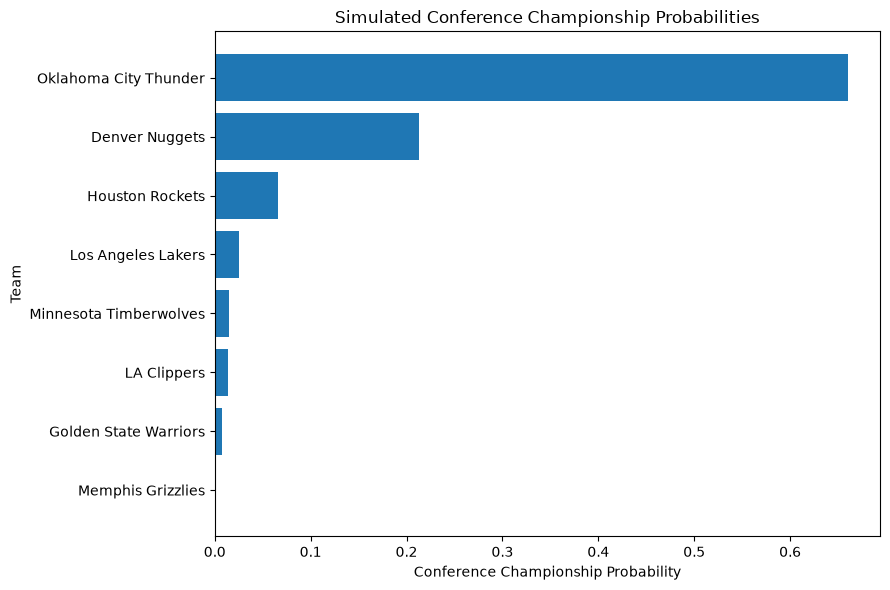

In [89]:
plot_results = conference_results.sort_values(
    "Conference Win Probability"
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_results["Team"],
    plot_results["Conference Win Probability"]
)

plt.xlabel("Conference Championship Probability")
plt.ylabel("Team")
plt.title("Simulated Conference Championship Probabilities")

plt.tight_layout()
plt.show()

In [90]:
conference_results.style.format(
    {
        "Conference Win Probability": "{:.1%}"
    }
)

,Team,Championships,Conference Win Probability
0,Oklahoma City Thunder,6607,66.1%
1,Denver Nuggets,2128,21.3%
7,Houston Rockets,664,6.6%
2,Los Angeles Lakers,250,2.5%
4,Minnesota Timberwolves,146,1.5%
3,LA Clippers,134,1.3%
6,Golden State Warriors,71,0.7%
5,Memphis Grizzlies,0,0.0%


In [91]:
conference_results["Conference Win Probability"].sum()

np.float64(1.0)

In [92]:
memphis_row = get_team_snapshot(
    df,
    "Memphis Grizzlies",
    snapshot_date
)

memphis_row[
    [
        "GAME_DATE",
        "SEASON_WIN_PCT",
        "WIN_PCT_ROLL5",
        "PLUS_MINUS_ROLL5",
        "REST_DAYS"
    ]
]

GAME_DATE           2026-04-12 00:00:00
SEASON_WIN_PCT                 0.308642
WIN_PCT_ROLL5                       0.0
PLUS_MINUS_ROLL5                  -25.4
REST_DAYS                           2.0
Name: 11069, dtype: object

#### Full 2025-2026 Season Simulation

In [95]:
simulation_season = "2025-26"

In [96]:
season_df = df[
    df["SEASON"] == simulation_season
].copy()

season_df = season_df.dropna(
    subset=features
)

print(season_df.shape)
season_df.head()

(2428, 77)


,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,...,OPP_REST_DAYS,PTS_ROLL5_DIFF,FG_PCT_ROLL5_DIFF,FG3_PCT_ROLL5_DIFF,REB_ROLL5_DIFF,AST_ROLL5_DIFF,TOV_ROLL5_DIFF,PLUS_MINUS_ROLL5_DIFF,WIN_PCT_ROLL5_DIFF,REST_DAYS_DIFF
329,22025,1610612737,ATL,Atlanta Hawks,0022500090,2025-10-24,ATL @ ORL,W,240,41,...,2.0,-7.000000,-0.045000,-0.11400,-12.00,2.000000,1.000000,-24.00,-1.000000,0.0
330,22025,1610612737,ATL,Atlanta Hawks,0022500101,2025-10-25,ATL vs. OKC,L,240,35,...,2.0,-18.500000,0.004500,0.01300,-12.00,2.500000,3.000000,-11.50,-0.500000,-1.0
331,22025,1610612737,ATL,Atlanta Hawks,0022500115,2025-10-27,ATL @ CHI,L,240,49,...,2.0,-2.833333,-0.020333,-0.04450,-8.00,-2.166667,-2.666667,-19.00,-0.666667,0.0
332,22025,1610612737,ATL,Atlanta Hawks,0022500130,2025-10-29,ATL @ BKN,W,240,44,...,2.0,-1.250000,-0.001250,-0.03775,2.25,2.250000,-2.000000,6.75,0.250000,0.0
333,22025,1610612737,ATL,Atlanta Hawks,0022500020,2025-10-31,ATL @ IND,W,240,51,...,2.0,0.550000,0.052800,0.01925,-10.00,5.700000,-1.900000,2.65,0.400000,0.0


In [97]:
season_df["WIN_PROBABILITY"] = logistic_model.predict_proba(
    season_df[features]
)[:, 1]

In [98]:
season_df[
    [
        "GAME_ID",
        "GAME_DATE",
        "TEAM_NAME",
        "WIN_PROBABILITY"
    ]
].head()

,GAME_ID,GAME_DATE,TEAM_NAME,WIN_PROBABILITY
329,0022500090,2025-10-24,Atlanta Hawks,0.142930
330,0022500101,2025-10-25,Atlanta Hawks,0.413471
331,0022500115,2025-10-27,Atlanta Hawks,0.274697
332,0022500130,2025-10-29,Atlanta Hawks,0.445126
333,0022500020,2025-10-31,Atlanta Hawks,0.491005


In [99]:
game_counts = (
    season_df.groupby("GAME_ID")
    .size()
    .value_counts()
)

game_counts

2    1214
Name: count, dtype: int64

In [100]:
season_df[
    season_df["GAME_ID"]
    == season_df["GAME_ID"].iloc[0]
][
    [
        "GAME_ID",
        "TEAM_NAME",
        "HOME_GAME",
        "WIN_PROBABILITY",
        "WIN"
    ]
]

,GAME_ID,TEAM_NAME,HOME_GAME,WIN_PROBABILITY,WIN
329,0022500090,Atlanta Hawks,0,0.142930,1
6889,0022500090,Orlando Magic,1,0.870836,0


In [102]:
games = season_df[
    season_df["HOME_GAME"] == 1
].copy()

print("Unique games:", games["GAME_ID"].nunique())
print("Rows:", len(games))

Unique games: 1209
Rows: 1209


In [104]:
away_lookup = (
    season_df[
        season_df["HOME_GAME"] == 0
    ][
        [
            "GAME_ID",
            "TEAM_NAME"
        ]
    ]
    .rename(
        columns={
            "TEAM_NAME": "AWAY_TEAM"
        }
    )
)

In [105]:
games = games.merge(
    away_lookup,
    on="GAME_ID",
    how="left"
)

games = games.rename(
    columns={
        "TEAM_NAME": "HOME_TEAM",
        "WIN_PROBABILITY": "HOME_WIN_PROBABILITY"
    }
)

In [106]:
games = games[
    [
        "GAME_ID",
        "GAME_DATE",
        "HOME_TEAM",
        "AWAY_TEAM",
        "HOME_WIN_PROBABILITY"
    ]
]

games.head()

,GAME_ID,GAME_DATE,HOME_TEAM,AWAY_TEAM,HOME_WIN_PROBABILITY
0,0022500101,2025-10-25,Atlanta Hawks,Oklahoma City Thunder,0.413471
1,0022500166,2025-11-04,Atlanta Hawks,Orlando Magic,0.495485
2,0022500030,2025-11-07,Atlanta Hawks,Toronto Raptors,0.554459
3,0022500185,2025-11-08,Atlanta Hawks,Los Angeles Lakers,0.411932
4,0022500251,2025-11-18,Atlanta Hawks,Detroit Pistons,0.633181


In [107]:
def simulate_season(
    games,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    standings = {}

    teams = pd.concat(
        [
            games["HOME_TEAM"],
            games["AWAY_TEAM"]
        ]
    ).unique()

    for team in teams:
        standings[team] = {
            "Wins": 0,
            "Losses": 0
        }

    for _, game in games.iterrows():
        home_team = game["HOME_TEAM"]
        away_team = game["AWAY_TEAM"]
        home_probability = game[
            "HOME_WIN_PROBABILITY"
        ]

        home_wins = (
            rng.random()
            < home_probability
        )

        if home_wins:
            standings[home_team]["Wins"] += 1
            standings[away_team]["Losses"] += 1
        else:
            standings[away_team]["Wins"] += 1
            standings[home_team]["Losses"] += 1

    standings_df = pd.DataFrame.from_dict(
        standings,
        orient="index"
    )

    standings_df.index.name = "Team"

    standings_df = standings_df.reset_index()

    standings_df["Games"] = (
        standings_df["Wins"]
        + standings_df["Losses"]
    )

    standings_df["Win Pct"] = (
        standings_df["Wins"]
        / standings_df["Games"]
    )

    return standings_df.sort_values(
        ["Wins", "Win Pct"],
        ascending=False
    )

In [116]:
simulated_standings = simulate_season(
    games,
    random_state=42
)

simulated_standings

,Team,Wins,Losses,Games,Win Pct
6,Denver Nuggets,53,28,81,0.654321
11,Miami Heat,53,28,81,0.654321
2,Cleveland Cavaliers,52,29,81,0.641975
23,Oklahoma City Thunder,51,28,79,0.645570
22,San Antonio Spurs,49,31,80,0.612500
18,Philadelphia 76ers,49,32,81,0.604938
1,Boston Celtics,48,33,81,0.592593
28,Detroit Pistons,46,34,80,0.575000
0,Atlanta Hawks,46,35,81,0.567901
19,Phoenix Suns,45,36,81,0.555556


In [121]:
print(
    simulated_standings["Wins"].sum()
)

print(
    len(games)
)

1209
1209


In [122]:
def simulate_many_seasons(
    games,
    n_simulations=1000,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    teams = sorted(
        pd.concat(
            [
                games["HOME_TEAM"],
                games["AWAY_TEAM"]
            ]
        ).unique()
    )

    win_totals = {
        team: []
        for team in teams
    }

    for _ in range(n_simulations):
        season_seed = int(
            rng.integers(
                0,
                1_000_000_000
            )
        )

        standings = simulate_season(
            games,
            random_state=season_seed
        )

        standings = standings.set_index(
            "Team"
        )

        for team in teams:
            win_totals[team].append(
                standings.loc[
                    team,
                    "Wins"
                ]
            )

    results = []

    for team in teams:
        wins = np.array(
            win_totals[team]
        )

        results.append(
            {
                "Team": team,
                "Average Wins": wins.mean(),
                "Win Std Dev": wins.std(),
                "10th Percentile": np.percentile(
                    wins,
                    10
                ),
                "90th Percentile": np.percentile(
                    wins,
                    90
                )
            }
        )

    return (
        pd.DataFrame(results)
        .sort_values(
            "Average Wins",
            ascending=False
        )
    )

In [123]:
season_simulation_results = (
    simulate_many_seasons(
        games,
        n_simulations=1000
    )
)

season_simulation_results

,Team,Average Wins,Win Std Dev,10th Percentile,90th Percentile
20,Oklahoma City Thunder,54.111,3.743351,49.0,59.0
26,San Antonio Spurs,49.761,4.139309,44.0,55.0
8,Detroit Pistons,49.179,4.088638,44.0,54.0
7,Denver Nuggets,47.151,4.317661,41.0,53.0
1,Boston Celtics,46.779,4.302576,41.0,52.0
5,Cleveland Cavaliers,45.926,4.196013,41.0,51.0
10,Houston Rockets,45.794,4.345292,40.0,51.0
19,New York Knicks,45.483,4.159533,40.0,51.0
13,Los Angeles Lakers,44.672,4.380002,39.0,50.0
27,Toronto Raptors,44.115,4.277122,39.0,50.0


In [ ]:
print(simulated_standings["Wins"].sum())
print(simulated_standings["Losses"].sum())
print(len(games))

1209
1209
1209
